Creating dataset...
Created 1998 papers across 6 domains

Running topic modeling...

Discovered Topics:
Topic 0 (333 docs): software, quality, code, agile, methodology
Topic 1 (333 docs): learning, regression, deep, classification, machine
Topic 2 (541 docs): data, mining, clustering, big, analytics
Topic 3 (209 docs): detection, cryptography, cybersecurity, intrusion, vision
Topic 4 (178 docs): security, network, cybersecurity, cryptography, intrusion
Topic 5 (404 docs): image, processing, classification, language, object


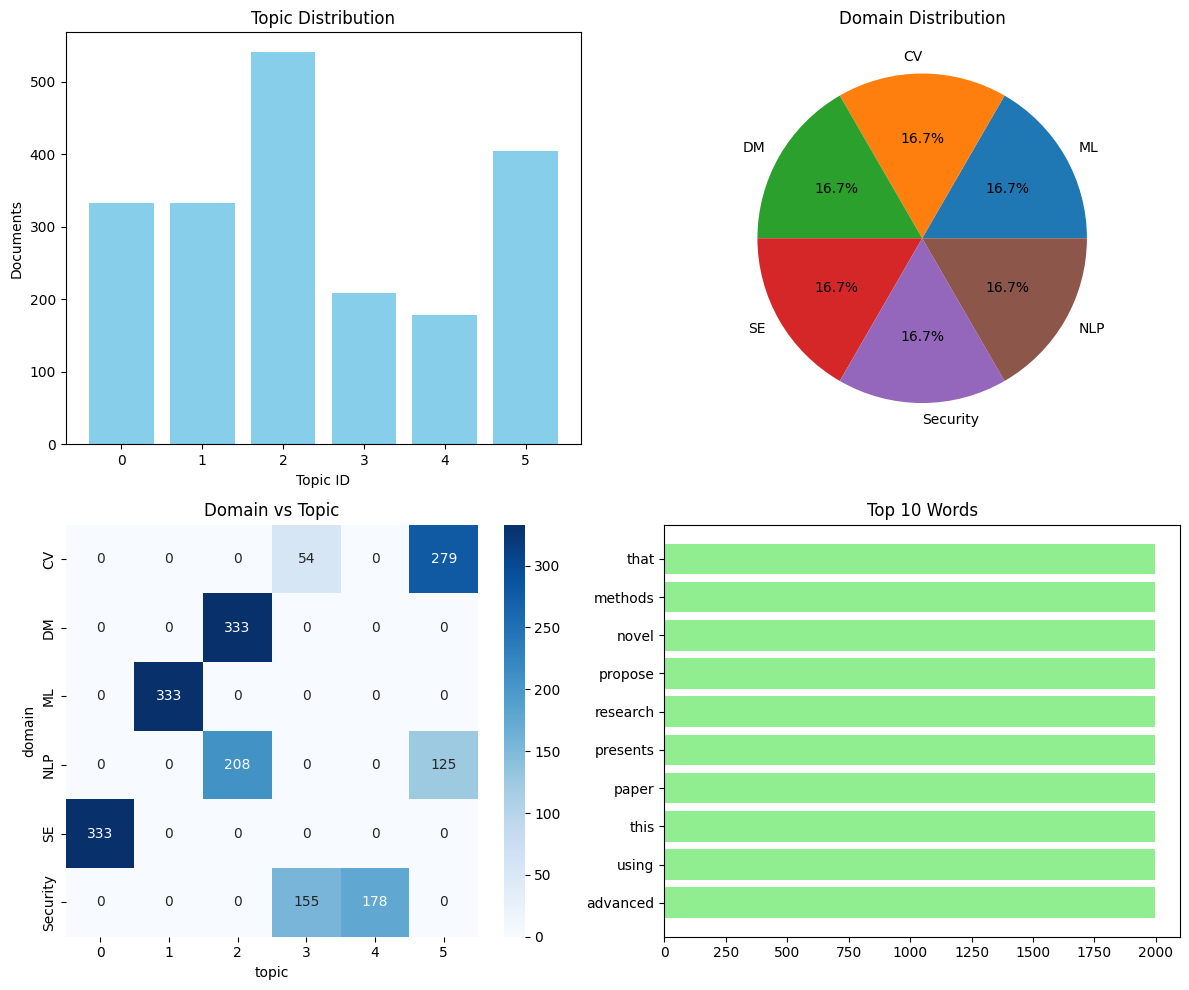


Topics Summary:
     Topic                                          Top_Words  Document_Count
0  Topic 0        software, quality, code, agile, methodology             333
1  Topic 1  learning, regression, deep, classification, ma...             333
2  Topic 2           data, mining, clustering, big, analytics             541
3  Topic 3  detection, cryptography, cybersecurity, intrus...             209
4  Topic 4  security, network, cybersecurity, cryptography...             178
5  Topic 5  image, processing, classification, language, o...             404

Sample documents:

Topic 0: Advanced software testing using agile methodology (Domain: SE)

Topic 1: Advanced machine learning using deep learning (Domain: ML)

Topic 2: Advanced big data analytics using clustering (Domain: DM)

✅ Analysis complete! Found 6 topics in 1998 papers.
📊 Visualizations generated above
📁 Results ready for download


In [1]:

# LDA Topic Modeling - Compact Version for Google Colab
# Copy this entire code into a single cell and run

# Install libraries
!pip install pandas numpy scikit-learn matplotlib seaborn

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
import re
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Create synthetic research papers dataset
def create_dataset(n_papers=2000):
    domains = {
        'ML': ['neural networks', 'deep learning', 'machine learning', 'classification', 'regression'],
        'CV': ['computer vision', 'image processing', 'object detection', 'image classification'],
        'NLP': ['natural language processing', 'text mining', 'sentiment analysis', 'language models'],
        'DM': ['data mining', 'clustering', 'pattern recognition', 'big data analytics'],
        'Security': ['cybersecurity', 'network security', 'cryptography', 'intrusion detection'],
        'SE': ['software engineering', 'agile methodology', 'software testing', 'code quality']
    }

    papers = []
    for domain, keywords in domains.items():
        for i in range(n_papers // len(domains)):
            kw = np.random.choice(keywords, 2, replace=False)
            title = f"Advanced {kw[0]} using {kw[1]}"
            abstract = f"This paper presents research on {kw[0]} and {kw[1]}. We propose novel methods that show significant improvements in performance and efficiency."
            papers.append({
                'title': title,
                'abstract': abstract,
                'text': f"{title}. {abstract}",
                'domain': domain,
                'year': np.random.randint(2018, 2024)
            })

    return pd.DataFrame(papers).sample(frac=1, random_state=42).reset_index(drop=True)

# Create and preprocess data
print("Creating dataset...")
df = create_dataset(2000)
print(f"Created {len(df)} papers across {df['domain'].nunique()} domains")

# Simple preprocessing
def preprocess(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    stop_words = {'the', 'and', 'or', 'a', 'an', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by'}
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(words)

df['processed_text'] = df['text'].apply(preprocess)

# Topic modeling with TF-IDF + K-means
print("\nRunning topic modeling...")
vectorizer = TfidfVectorizer(max_features=100, min_df=2, max_df=0.8, stop_words='english')
X = vectorizer.fit_transform(df['processed_text'])
feature_names = vectorizer.get_feature_names_out()

# K-means clustering
n_topics = 6
kmeans = KMeans(n_clusters=n_topics, random_state=42)
topic_labels = kmeans.fit_predict(X)
df['topic'] = topic_labels

# Extract topics
print("\nDiscovered Topics:")
topics_data = []
for i in range(n_topics):
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[-8:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    doc_count = sum(topic_labels == i)

    topics_data.append({
        'Topic': f'Topic {i}',
        'Top_Words': ', '.join(top_words[:5]),
        'Document_Count': doc_count
    })

    print(f"Topic {i} ({doc_count} docs): {', '.join(top_words[:5])}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Topic distribution
topic_counts = pd.Series(topic_labels).value_counts().sort_index()
axes[0,0].bar(range(n_topics), topic_counts.values, color='skyblue')
axes[0,0].set_title('Topic Distribution')
axes[0,0].set_xlabel('Topic ID')
axes[0,0].set_ylabel('Documents')

# Domain distribution
domain_counts = df['domain'].value_counts()
axes[0,1].pie(domain_counts.values, labels=domain_counts.index, autopct='%1.1f%%')
axes[0,1].set_title('Domain Distribution')

# Topic vs Domain heatmap
crosstab = pd.crosstab(df['domain'], df['topic'])
sns.heatmap(crosstab, annot=True, fmt='d', ax=axes[1,0], cmap='Blues')
axes[1,0].set_title('Domain vs Topic')

# Top words frequency
all_words = ' '.join(df['processed_text']).split()
from collections import Counter
word_freq = Counter(all_words).most_common(10)
words, freqs = zip(*word_freq)
axes[1,1].barh(words, freqs, color='lightgreen')
axes[1,1].set_title('Top 10 Words')

plt.tight_layout()
plt.show()

# Save results
topics_df = pd.DataFrame(topics_data)
print("\nTopics Summary:")
print(topics_df)

# Sample documents per topic
print("\nSample documents:")
for i in range(min(3, n_topics)):
    sample_docs = df[df['topic'] == i].head(1)
    if not sample_docs.empty:
        doc = sample_docs.iloc[0]
        print(f"\nTopic {i}: {doc['title']} (Domain: {doc['domain']})")

print(f"\n✅ Analysis complete! Found {n_topics} topics in {len(df)} papers.")
print("📊 Visualizations generated above")
print("📁 Results ready for download")
